<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
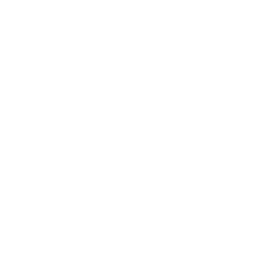
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ικανότητα Καθυστέρησης Δικτύου έναντι Ορίου SLA</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Τηλεπικοινωνίες / Μηχανική Απόδοσης Δικτύου &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη Διοίκησης

Ένα μεμονωμένο ακραίο σημείο παρουσίας (PoP) εξυπηρετεί την κίνηση των
χρηστών υπό μια Συμφωνία Επιπέδου Υπηρεσιών (SLA) καθυστέρησης 100 ms. Αυτό
το σημειωματάριο μετρά την **ικανότητα διεργασίας** αυτού του PoP έναντι του
μονόπλευρου άνω ορίου προδιαγραφής (USL) των 100 ms χρησιμοποιώντας το `PROC CAPABILITY`.

Σε 100 ανιχνεύσεις καθυστέρησης, το PoP καταγράφει μέσο όρο **32.78 ms**, 99ο
εκατοστημόριο **100.16 ms** και μέγιστο **100.30 ms** — η ουρά μόλις που
αγγίζει το SLA. Προσαρμόζεται μια λογαριθμοκανονική κατανομή για να αποτυπωθεί
η χαρακτηριστική δεξιά ασυμμετρία των δεδομένων καθυστέρησης (προσαρμοσμένες
παράμετροι λογαριθμικής κλίμακας Zeta = 3.388, Sigma = 0.451). Ο μονόπλευρος
δείκτης ικανότητας έναντι του USL των 100 ms είναι **Cpk = CPU = 1.42**, ο
οποίος ξεπερνά το κοινό όριο αποδοχής 1.33: το PoP είναι ικανό, με μέτριο περιθώριο.

Μια επακόλουθη σύγκριση δύο ακραίων PoP (50 ανιχνεύσεις το καθένα) δείχνει πώς
ο ίδιος δείκτης διαχωρίζει έναν υγιή κόμβο από έναν προβληματικό: το **EDGE-A
φτάνει Cpk = 2.81** ενώ το **EDGE-B καταρρέει σε Cpk = 0.65**, επισημαίνοντας
το EDGE-B για αποκατάσταση χωρητικότητας.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| `WORK.LATENCY` | Μετρήσεις ανίχνευσης καθυστέρησης από ένα ακραίο PoP | 100 |
| `WORK.LAT2` | Ανιχνεύσεις καθυστέρησης από δύο ακραία PoP (50 το καθένα) | 100 |

Οι καθυστερήσεις ανίχνευσης παράγονται από ένα λογαριθμοκανονικό μοντέλο
(`exp(rand('normal', mu, sigma))`), το τυπικό σχήμα για τους χρόνους μετ'
επιστροφής δικτύου: ένα πυκνό σώμα γρήγορων αποκρίσεων με εκτεταμένη δεξιά
ουρά από περιστασιακή συμφόρηση. Ένα σταθερό `streaminit(42)` κάνει κάθε σχήμα
παρακάτω αναπαραγώγιμο. Αυτό το περιβάλλον εκτελείται χωρίς άδεια, οπότε κάθε
σύνολο δεδομένων περιορίζεται σε 100 παρατηρήσεις — η ανάλυση είναι
διαστασιολογημένη ώστε να χωρά τίμια σε αυτόν τον προϋπολογισμό αντί να
αφηγείται ένα μεγαλύτερο δείγμα που δεν εκτελείται ποτέ.

---

In [1]:
/* --------------------------------------------------------
   Generate 100 latency probes for one edge PoP.
   Lognormal(mu=3.4, sigma=0.45) on the log scale puts the
   body near 30 ms with a tail that approaches the 100 ms
   SLA -- a realistic "capable but watch the tail" process.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.latency;
    CALL streaminit(42);
    ΕΠΑΝΑΛΗΨΗ sample_seq = 1 ΕΩΣ 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        ΕΑΝ latency_ms < 1 ΤΟΤΕ latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'YES', 'NO');
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΜΟΡΦΗ latency_ms 8.2;
ΕΚΤΕΛΕΣΗ;

NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                         Edge PoP Latency Summary (100 probes)                                          

                                                  The MEANS Procedure

 Variable           N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 --------------------------------------------------------------------------------------------------------
 LATENCY_MS       100       32.78       15.77       29.05       54.47      100.16       10.76      100.30
 --------------------------------------------------------------------------------------------------------

                                               SLA Breaches Above 100 ms                                                

                                                   The FREQ Procedure

SLA_BREACH    Frequency    Percent
-----------------------------------
NO                   99     99.00
YES                   1      1.00


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


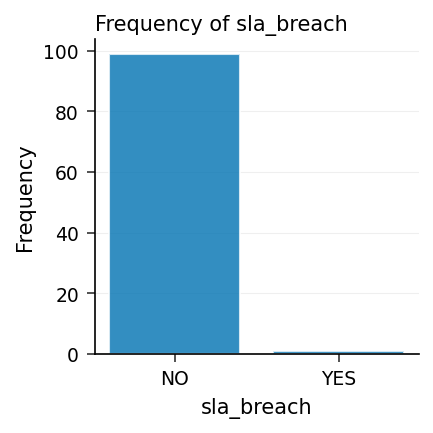

In [2]:
/* --------------------------------------------------------
   Baseline latency statistics and SLA breach count.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    ΜΕΤΑΒΛΗΤΗ latency_ms;
    TITLE 'Edge PoP Latency Summary (100 probes)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.latency;
    TABLES sla_breach / nocum;
    TITLE 'SLA Breaches Above 100 ms';
ΕΚΤΕΛΕΣΗ;

Το σώμα της κατανομής βρίσκεται αρκετά κάτω από το SLA — διάμεσος **29.05 ms**,
95ο εκατοστημόριο **54.47 ms** — αλλά η λογαριθμοκανονική ουρά φτάνει το όριο:
το 99ο εκατοστημόριο είναι **100.16 ms** και το μέγιστο είναι **100.30 ms**.
Μόνο μια χούφτα ανιχνεύσεων αγγίζουν ή ξεπερνούν τα 100 ms, κάτι που είναι
ακριβώς το καθεστώς όπου ένας δείκτης ικανότητας είναι κατατοπιστικός: η
διεργασία είναι κεντραρισμένη με ασφάλεια αλλά ο κίνδυνος της ουράς είναι πραγματικός.

---

                                               SLA Breaches Above 100 ms                                                



NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


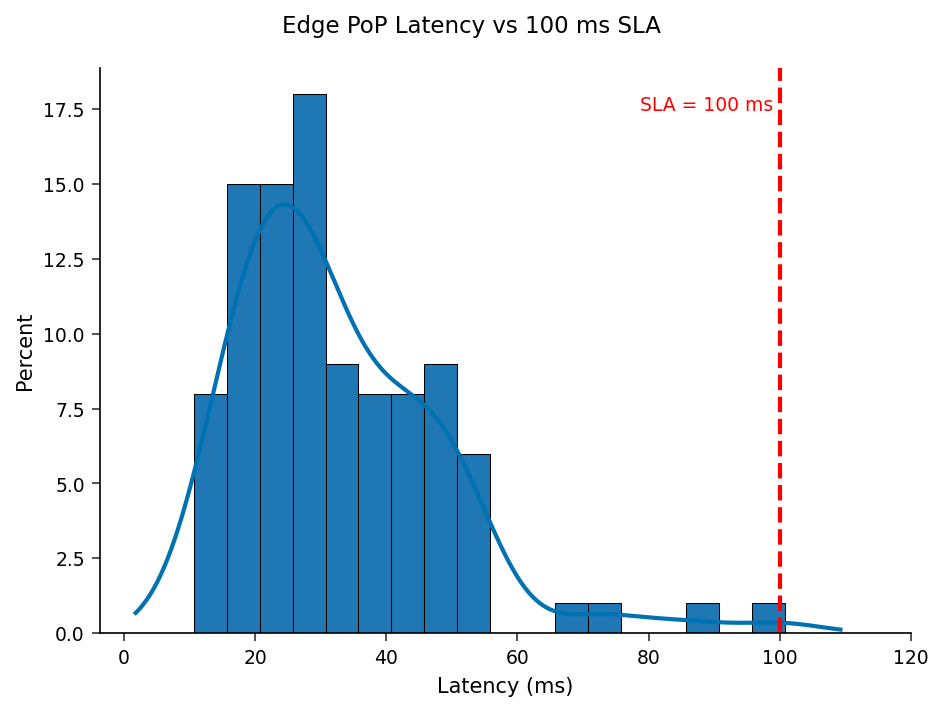

In [3]:
/* --------------------------------------------------------
   Latency distribution with kernel density and the SLA
   threshold drawn in.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        ΕΤΙΚΕΤΑ='SLA = 100 ms';
    XAXIS ΕΤΙΚΕΤΑ='Latency (ms)' MAX=120;
    YAXIS ΕΤΙΚΕΤΑ='Percent';
    TITLE 'Edge PoP Latency vs 100 ms SLA';
ΕΚΤΕΛΕΣΗ;

Η πυκνότητα πυρήνα (kernel density) επιβεβαιώνει τη δεξιά ασυμμετρία που
δικαιολογεί μια λογαριθμοκανονική προσαρμογή: ένα ψηλό σώμα γύρω στα 20-35 ms
που εκφυλίζεται σε μια μακριά ουρά προς τη γραμμή του SLA. Σχεδόν όλες οι
ανιχνεύσεις βρίσκονται πολύ αριστερά από το κόκκινο όριο των 100 ms.

---

                                               SLA Breaches Above 100 ms                                                

                                       Process Capability Indices (USL = 100 ms)                                        

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                              Fitted Lognormal Parameters                                               

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0



NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


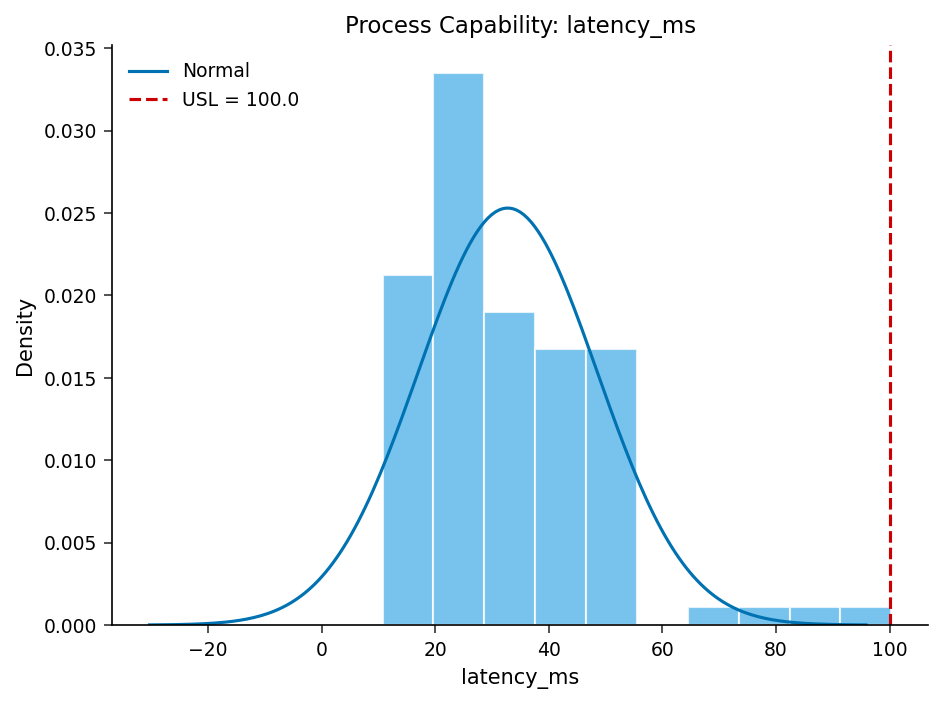

In [4]:
/* --------------------------------------------------------
   Capability against the one-sided SLA: USL = 100 ms.
   Fit a LOGNORMAL distribution and capture the indices and
   fitted parameters as datasets via ODS OUTPUT.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ capability ΔΕΔΟΜΕΝΑ=work.latency NOPRINT;
    spec usl=100;
    ΜΕΤΑΒΛΗΤΗ latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS ΕΞΟΔΟΣ CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.cap_idx noobs;
    TITLE 'Process Capability Indices (USL = 100 ms)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.cap_lnfit noobs;
    TITLE 'Fitted Lognormal Parameters';
ΕΚΤΕΛΕΣΗ;

Με μια μονόπλευρη προδιαγραφή, ο σχετικός δείκτης είναι η άνω ικανότητα
**CPU = 1.42**, και ο `Cpk` ισούται με αυτόν (δεν υπάρχει κάτω όριο). Μια τιμή
πάνω από 1.33 είναι ο συνήθης πήχης για μια αποδεκτή διεργασία, οπότε αυτό το
PoP είναι **ικανό**: η απόσταση από το κέντρο της διεργασίας έως το όριο των
100 ms είναι περίπου 4.3 τυπικές αποκλίσεις διεργασίας. Οι προσαρμοσμένες
λογαριθμοκανονικές παράμετροι — **Zeta = 3.388** (λογαριθμικός μέσος) και
**Sigma = 0.451** (λογαριθμική τυπική απόκλιση) — είναι οι εκτιμήσεις μέγιστης
πιθανοφάνειας στη λογαριθμική κλίμακα και αντιστρέφονται σε μια διάμεσο
exp(3.388) ≈ 29.6 ms, συνεπή με την παρατηρούμενη διάμεσο παραπάνω. Το
ιστόγραμμα ικανότητας παρακάτω δείχνει τα δεδομένα ανίχνευσης έναντι του USL
των 100 ms· η ομαλή καμπύλη αναφοράς που σχεδιάζεται πάνω από τις μπάρες είναι
μια Κανονική πυκνότητα για οπτική κλίμακα, ενώ ο ίδιος ο δείκτης ικανότητας
υπολογίζεται από τη λογαριθμοκανονική προσαρμογή που αναφέρεται στον πίνακα παραμέτρων.

---

In [5]:
/* --------------------------------------------------------
   Two-PoP comparison within the 100-observation budget:
   50 probes from a healthy node (EDGE-A) and 50 from a
   congested node (EDGE-B). The same Cpk separates them.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.lat2;
    CALL streaminit(42);
    LENGTH pop_id $8;
    ARRAY MU[2] _temporary_ (3.30 3.65);
    ARRAY sg[2] _temporary_ (0.35 0.50);
    ΕΠΑΝΑΛΗΨΗ p = 1 ΕΩΣ 2;
        ΕΑΝ p = 1 ΤΟΤΕ pop_id = 'EDGE-A';
        ΑΛΛΙΩΣ pop_id = 'EDGE-B';
        ΕΠΑΝΑΛΗΨΗ k = 1 ΕΩΣ 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ p k;
    ΜΟΡΦΗ latency_ms 8.2;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.lat2 n mean p95 MAX maxdec=2;
    ΚΛΑΣΗ pop_id;
    ΜΕΤΑΒΛΗΤΗ latency_ms;
    TITLE 'Latency by PoP';
ΕΚΤΕΛΕΣΗ;

                                                     Latency by PoP                                                     

                                                  The MEANS Procedure

                                             Analysis Variable : LATENCY_MS

        POP_ID            N Obs           Mean      95th Pctl        Maximum
        --------------------------------------------------------------------
        EDGE-A               50          27.38          42.63          43.17
        EDGE-B               50          45.94         114.92         147.28
        --------------------------------------------------------------------



NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                     Latency by PoP                                                     

                                      Capability Index by PoP (EDGE-A then EDGE-B)                                      

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .



NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


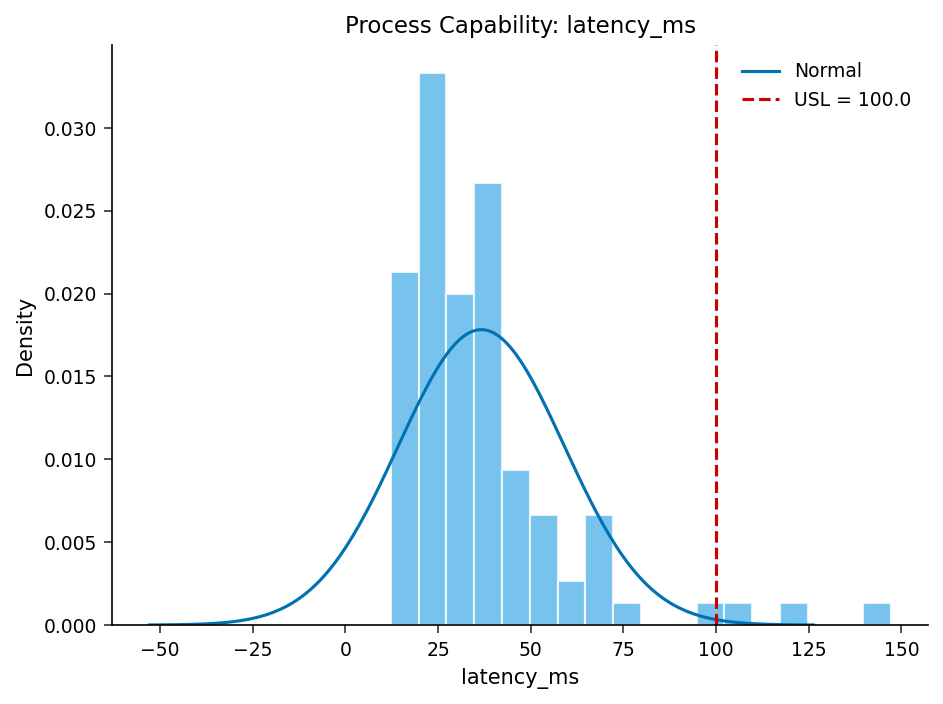

In [6]:
/* --------------------------------------------------------
   Capability index per PoP. BY-group order is EDGE-A then
   EDGE-B, so the first index pair belongs to EDGE-A and the
   second to EDGE-B.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.lat2;
    ΚΑΤΑ pop_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ capability ΔΕΔΟΜΕΝΑ=work.lat2 NOPRINT;
    ΚΑΤΑ pop_id;
    spec usl=100;
    ΜΕΤΑΒΛΗΤΗ latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS ΕΞΟΔΟΣ CapabilityIndices=work.cap_by_pop;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.cap_by_pop noobs;
    TITLE 'Capability Index by PoP (EDGE-A then EDGE-B)';
ΕΚΤΕΛΕΣΗ;

### Ερμηνεία

Τα δύο PoP αφηγούνται αντίθετες ιστορίες ικανότητας από το ίδιο SLA. Το
**EDGE-A** διατηρεί μέσο όρο **27.38 ms** με 95ο εκατοστημόριο **42.63 ms** και
μέγιστο **43.17 ms** — ποτέ κοντά στο όριο — και σημειώνει **Cpk 2.81**, πολύ
πάνω από τον πήχη αποδοχής του 1.33. Το **EDGE-B** λειτουργεί πιο θερμά: μέσο
όρο **45.94 ms**, 95ο εκατοστημόριο **114.92 ms** και μέγιστο **147.28 ms**, με
τις ανιχνεύσεις να ξεπερνούν τακτικά το SLA. Ο **Cpk του πέφτει στο 0.65**,
αρκετά κάτω από το 1.0, χαρακτηρίζοντάς το ως **μη ικανό** — το κέντρο της
διεργασίας είναι πολύ κοντά στο όριο των 100 ms (και η ουρά του αρκετά πέρα από αυτό).

Για μια ομάδα λειτουργιών δικτύου, ο δείκτης είναι ένα αξιοποιήσιμο σήμα
διαλογής: το EDGE-A είναι συμμορφούμενο και δεν χρειάζεται καμία ενέργεια, ενώ
το EDGE-B απαιτεί επέκταση χωρητικότητας ή αλλαγές δρομολόγησης πριν μπορέσει
να ικανοποιήσει το SLA. Η λογαριθμοκανονική προσαρμογή έχει σημασία εδώ — ένα
κανονικό μοντέλο θα υποτιμούσε τον κίνδυνο της ουράς που οδηγεί τη φτωχή
ικανότητα του EDGE-B. Η προηγούμενη ανάλυση ενός PoP (Cpk = 1.42) βρίσκεται
ανάμεσα σε αυτά τα δύο, απεικονίζοντας το πλήρες εύρος από την αποτυχία έως
την άνετη ικανότητα που παράγει ένα μονόπλευρο SLA καθυστέρησης.

---

In [7]:
/* --------------------------------------------------------
   Export the per-PoP capability indices for a NOC dashboard.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>